# N5 · Pocket-Price Waterfall — the leakage audit

**Panel question** — asked by the **CRO/CCO**: *"You have 8 weeks to show
pricing quick wins. What do you do?"*

The answer is **leakage-first**: management fixates on the headline rate while
the real erosion is transaction-level — invisible until you build the
waterfall (Marn & Rosiello, HBR 1992). This notebook builds one for FX cash,
sizes every leakage bucket, shows the *variance across branches is itself the
finding*, prices the 1%-realised-price lever, and designs the holdout that
proves the fix honestly.

**Contract:** known leakage injected → headline P&L hides it → waterfall
reveals it → recovery plan ranked by £ × ease → holdout attribution.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import C, apply_style
apply_style()

rng = np.random.default_rng(7)

# --- One year of branch-network FX sell transactions -----------------------
# We simulate a 2% transaction sample and gross up: reported £ figures are
# network-scale (~£1.4bn/yr cash sell — directional, not audited).
N_BR, N_TX = 250, 40_000
GROSS = 50                         # 2% sample -> network scale
HEADLINE_BPS = 500                 # headline spread over wholesale (5.0%)
HEDGE_BPS = 8                      # interbank -> wholesale (hedging + funding)

tx = pd.DataFrame({
    "branch": rng.integers(0, N_BR, N_TX),
    "value": np.clip(rng.lognormal(np.log(520), 0.75, N_TX), 40, 12_000),
    "online": rng.random(N_TX) < 0.35,
})

# --- Inject KNOWN leakage buckets (bps given away vs headline) --------------
leak = pd.DataFrame(index=tx.index)

# 1. Order-size tiers (>=£500: -40bps, >=£1,000: -70bps) — legitimate pricing
#    architecture, so NOT leakage...
tier = np.where(tx.value >= 1000, 70, np.where(tx.value >= 500, 40, 0))
# ...but 9% of BELOW-threshold orders get a tier rate anyway (miskeyed): leakage.
misapplied = (tier == 0) & (rng.random(N_TX) < 0.09)
leak["tier_misapplied"] = np.where(misapplied, 40, 0)

# 2. Promo codes on online orders (a quarter of online volume, -25bps).
leak["promo"] = np.where(tx.online & (rng.random(N_TX) < 0.25), 25, 0)

# 3. Staff / partner rates (2% of txns, -150bps).
leak["staff_partner"] = np.where(rng.random(N_TX) < 0.02, 150, 0)

# 4. Click-&-collect rate lock: we honour the ordered rate when the market moves
#    against us between order and collection (adverse-only, online volume).
cc = tx.online & (rng.random(N_TX) < 0.85)
leak["cc_rate_lock"] = np.where(cc, np.maximum(rng.normal(0, 18, N_TX), 0), 0)

# 5. Branch manual overrides — discretionary discounts, CONCENTRATED in a tail
#    of branches (the real-world signature of unmanaged discounting).
override_prone = rng.random(N_BR) < 0.15          # 15% of branches do most of it
p_ovr = np.where(override_prone[tx.branch], 0.22, 0.02)
leak["override"] = np.where(rng.random(N_TX) < p_ovr,
                            rng.uniform(30, 100, N_TX), 0)

tx["tier"] = tier
tx["leak_bps"] = leak.sum(axis=1)
tx["pocket_bps"] = HEADLINE_BPS - tier - tx.leak_bps - HEDGE_BPS
print(f"Headline spread: {HEADLINE_BPS}bps | mean pocket spread: "
      f"{np.average(tx.pocket_bps, weights=tx.value):.0f}bps")

Headline spread: 500bps | mean pocket spread: 435bps


## 1. What the headline P&L shows — nothing wrong

Total spread revenue looks healthy. Nobody sees the erosion, because every
bucket is small *per transaction* and lives in a different system.

In [2]:
tx["rev"] = tx.value * tx.pocket_bps / 1e4
print(f"Annual sell volume : £{tx.value.sum()*GROSS/1e9:,.2f}bn")
print(f"Spread revenue     : £{tx.rev.sum()*GROSS/1e6:,.1f}m")
print(f"Revenue as % load  : {tx.rev.sum()/tx.value.sum():.2%}  "
      "(a board pack shows this line and moves on)")

Annual sell volume : £1.37bn
Spread revenue     : £59.8m
Revenue as % load  : 4.35%  (a board pack shows this line and moves on)


## 2. The waterfall — per £1,000 transacted, in bps

Now decompose the same revenue the way Marn & Rosiello do: headline → each
giveaway → pocket. Tier discounts are *pricing architecture* (intentional);
everything after them is **leakage**.

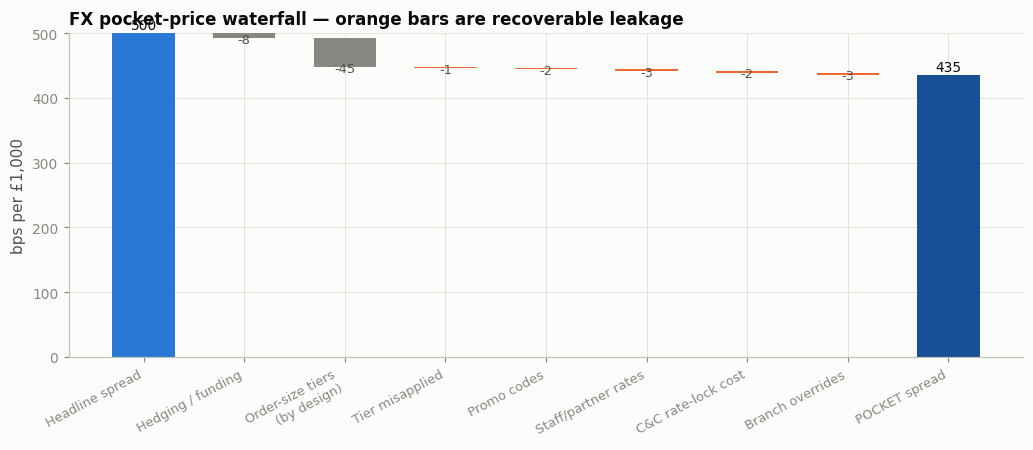

Headline 500 -> pocket 435bps. Recoverable leakage: 12bps = £1.58m/yr at network scale


In [3]:
w = tx.value.to_numpy()
def wavg(col): return float(np.average(col, weights=w))

steps = [
    ("Headline spread", HEADLINE_BPS),
    ("Hedging / funding", -HEDGE_BPS),
    ("Order-size tiers (by design)", -wavg(tx.tier)),
    ("Tier misapplied", -wavg(leak.tier_misapplied)),
    ("Promo codes", -wavg(leak.promo)),
    ("Staff/partner rates", -wavg(leak.staff_partner)),
    ("C&C rate-lock cost", -wavg(leak.cc_rate_lock)),
    ("Branch overrides", -wavg(leak.override)),
]
pocket = sum(v for _, v in steps)
labels = [s[0] for s in steps] + ["POCKET spread"]
vals = [s[1] for s in steps] + [pocket]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
run = 0.0
for i, (lab, v) in enumerate(zip(labels, vals)):
    if i == 0 or i == len(vals) - 1:
        ax.bar(i, v, color=C["blue"] if i == 0 else C["seq"][5], width=0.62)
        ax.text(i, v + 6, f"{v:.0f}", ha="center", fontsize=9, color=C["ink"])
        run = v if i == 0 else run
    else:
        ax.bar(i, v, bottom=run, color=C["orange"] if lab != "Order-size tiers (by design)"
               and lab != "Hedging / funding" else C["muted"], width=0.62)
        ax.text(i, run + v - 7, f"{v:.0f}", ha="center", fontsize=8.5, color=C["ink2"])
        run += v
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([l.replace(" (by design)", "\n(by design)") for l in labels],
                   rotation=28, ha="right", fontsize=8.5)
ax.set_ylabel("bps per £1,000")
ax.set_title("FX pocket-price waterfall — orange bars are recoverable leakage")
plt.tight_layout(); plt.show()

leak_bps_total = -sum(v for lab, v in steps
                      if lab in ("Tier misapplied", "Promo codes", "Staff/partner rates",
                                 "C&C rate-lock cost", "Branch overrides"))
print(f"Headline {HEADLINE_BPS} -> pocket {pocket:.0f}bps. "
      f"Recoverable leakage: {leak_bps_total:.0f}bps "
      f"= £{leak_bps_total/1e4 * tx.value.sum()*GROSS/1e6:,.2f}m/yr at network scale")

## 3. Rank the buckets: £ recoverable × ease of fix

An 8-week window can't fix everything. Rank by recoverable value times a
realistic ease score (1 = hard governance change, 3 = systems flag).

In [4]:
buckets = pd.DataFrame({
    "bucket": ["tier_misapplied", "promo", "staff_partner", "cc_rate_lock", "override"],
    "annual_m": [leak[b].mul(tx.value).sum() * GROSS / 1e4 / 1e6
                 for b in ["tier_misapplied", "promo", "staff_partner",
                           "cc_rate_lock", "override"]],
    # ease: misapplied tiers = POS validation (easy); overrides = approval tiers
    # (medium); promo = marketing negotiation; c&c = hedge the lock; staff = policy
    "ease_1to3": [3, 2, 2, 1, 2],
    "recover_share": [0.9, 0.4, 0.5, 0.6, 0.6],
})
buckets["recoverable_m"] = buckets["annual_m"] * buckets["recover_share"]
buckets["priority"] = buckets["recoverable_m"] * buckets["ease_1to3"]
buckets = buckets.sort_values("priority", ascending=False)
print(buckets.round(3).to_string(index=False))
top2 = buckets.head(2)
print(f"\n8-week plan: fix '{top2.iloc[0]['bucket']}' and '{top2.iloc[1]['bucket']}' "
      f"-> £{top2['recoverable_m'].sum():.2f}m/yr recoverable")

         bucket  annual_m  ease_1to3  recover_share  recoverable_m  priority
       override     0.480          2            0.6          0.288     0.576
  staff_partner     0.401          2            0.5          0.201     0.401
tier_misapplied     0.104          3            0.9          0.094     0.281
          promo     0.298          2            0.4          0.119     0.238
   cc_rate_lock     0.300          1            0.6          0.180     0.180

8-week plan: fix 'override' and 'staff_partner' -> £0.49m/yr recoverable


## 4. The variance across branches IS the finding

The network average hides a tail of branches giving away 2–4× the median.
That tail is where the 8-week win lives — and it's a *governance* fix
(approval tiers), not a modelling one.

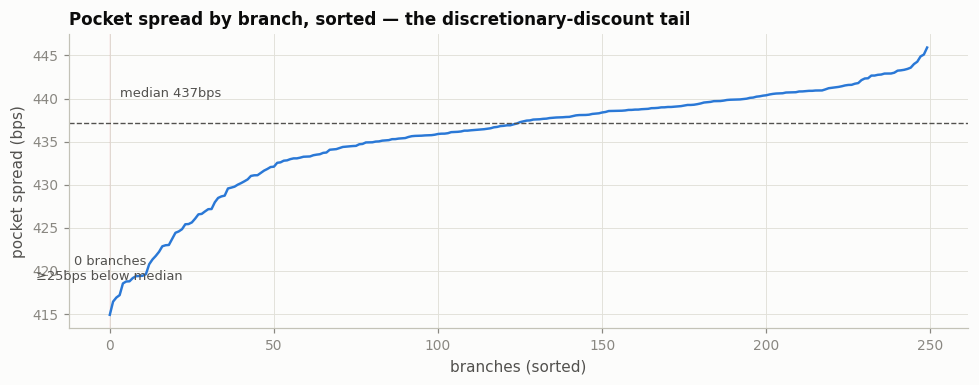

In [5]:
g = tx.assign(w_rev=tx.pocket_bps * tx.value).groupby("branch")[["w_rev", "value"]].sum()
br = (g.w_rev / g.value).sort_values()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(range(len(br)), br.values, color=C["blue"], lw=1.6)
ax.axhline(br.median(), color=C["ink2"], lw=0.9, ls="--")
ax.text(3, br.median() + 3, f"median {br.median():.0f}bps", fontsize=8.5, color=C["ink2"])
n_tail = int((br < br.median() - 25).sum())
ax.axvspan(0, n_tail, color=C["critical"], alpha=0.08)
ax.text(n_tail / 2, br.min() + 4, f"{n_tail} branches\n≥25bps below median",
        ha="center", fontsize=8.5, color=C["ink2"])
ax.set_title("Pocket spread by branch, sorted — the discretionary-discount tail")
ax.set_xlabel("branches (sorted)"); ax.set_ylabel("pocket spread (bps)")
plt.tight_layout(); plt.show()

## 5. The Marn & Rosiello lever, computed on THIS business

+1% realised price vs −1% variable cost vs +1% volume, on the same P&L.
(HBR 1992 found ~11.1% operating-profit leverage for the average company;
here we compute it rather than quote it.)

In [6]:
revenue = tx.rev.sum() * GROSS
var_cost = 0.60 * revenue            # cash logistics, processing, commission
fix_cost = 0.31 * revenue            # branches, staff, overheads (9% op margin)
op_profit = revenue - var_cost - fix_cost

levers = pd.DataFrame({
    "lever": ["+1% realised price (volume flat)", "-1% variable cost",
              "+1% volume (price flat)", "-1% fixed cost"],
    "new_profit": [
        revenue * 1.01 - var_cost - fix_cost,
        revenue - var_cost * 0.99 - fix_cost,
        revenue * 1.01 - var_cost * 1.01 - fix_cost,
        revenue - var_cost - fix_cost * 0.99,
    ],
})
levers["op_profit_uplift_%"] = (levers.new_profit / op_profit - 1) * 100
print(f"Operating profit: £{op_profit/1e6:.2f}m on £{revenue/1e6:.2f}m spread revenue")
print(levers[["lever", "op_profit_uplift_%"]].round(2).to_string(index=False))
print("\nPrice is the biggest lever — and leakage recovery IS realised-price improvement.")

Operating profit: £5.38m on £59.76m spread revenue
                           lever  op_profit_uplift_%
+1% realised price (volume flat)               11.11
               -1% variable cost                6.67
         +1% volume (price flat)                4.44
                  -1% fixed cost                3.44

Price is the biggest lever — and leakage recovery IS realised-price improvement.


## 6. Prove it honestly: the holdout design

Ship the top fix (POS validation on tier rates + override approval tiers) to
80% of branches; hold out 20%. A market tailwind arrives at the same time —
exactly the situation where naive before/after over-claims.

In [7]:
FIX_RECOVERY = 0.75          # the fix recovers 75% of the two targeted buckets
MARKET_DRIFT = 0.03          # demand tailwind hitting ALL branches

fixed_buckets = leak.tier_misapplied + leak.override
gain_bps = FIX_RECOVERY * fixed_buckets
holdout = rng.random(N_BR) < 0.20
in_hold = holdout[tx.branch]

rev_before = tx.rev
rev_after = np.where(in_hold,
                     rev_before * (1 + MARKET_DRIFT),
                     (tx.value * (tx.pocket_bps + gain_bps) / 1e4) * (1 + MARKET_DRIFT))

naive_claim = rev_after.sum() / rev_before.sum() - 1
did = (rev_after[~in_hold].sum() / rev_before[~in_hold].sum()
       - rev_after[in_hold].sum() / rev_before[in_hold].sum())
true_fix = (tx.value * gain_bps / 1e4)[~in_hold].sum() / rev_before[~in_hold].sum()

print(f"Naive before/after claim : +{naive_claim:.2%}   (fix + tailwind, over-claimed)")
print(f"Holdout DiD estimate     : +{did:.2%}")
print(f"True fix effect (known)  : +{true_fix:.2%}   <- DiD recovers it; the naive claim ~2x it")
print("\nReport: 'we estimate £X m, of which £Y m is cleanly attributable via the "
      "holdout; the rest is market.' Under-claim. Always.")

Naive before/after claim : +3.56%   (fix + tailwind, over-claimed)
Holdout DiD estimate     : +0.73%
True fix effect (known)  : +0.71%   <- DiD recovers it; the naive claim ~2x it

Report: 'we estimate £X m, of which £Y m is cleanly attributable via the holdout; the rest is market.' Under-claim. Always.


## The 60-second answer

> "Before I'd build any elasticity model, I'd run a price-leakage audit —
> because the headline spread says five hundred basis points while the pocket
> spread, after misapplied tiers, promo codes, staff rates, the click-and-collect
> rate lock and discretionary branch overrides, is materially lower. In this
> worked example that gap is worth over a million a year, and the biggest slice
> sits in a small tail of branches — which makes it a governance fix, approval
> tiers and a POS validation flag, not a modelling programme. That lands inside
> eight weeks.
>
> It matters because realised price is the biggest lever on the P&L — a one
> percent improvement in pocket price is worth roughly eleven percent of
> operating profit on this cost structure, several times the volume lever.
>
> And I'd prove it honestly: hold out twenty percent of branches, measure
> difference-in-differences, and report the cleanly-attributable number
> separately from the market tailwind — because the fastest way to lose a CFO
> is to claim the market's win as your own."

### What I'd say if pushed deeper

1. **"Why not just optimise the headline rate instead?"** — Optimisation moves
   the list price; leakage erodes whatever list you set. Fixing execution first
   also cleans the data an elasticity model would train on.
2. **"How do you keep the network onside while tightening overrides?"** — I'd
   co-design the approval tiers with the regional sales support managers and
   keep a legitimate discretion band — the goal is *managed* discretion, not
   zero discretion. Blindsided teams discount it away.
3. **Honest limitation.** The bucket sizes here are simulated; in reality the
   audit's first two weeks are data engineering — reconciling POS, promo and
   override logs that live in different systems. I'd budget more time for
   building the waterfall than for analysing it, and say so up front.